In [100]:
# იმპორტები
from tensorflow.keras.preprocessing.sequence import pad_sequences
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error
import pandas as pd  
import tensorflow as tf
import numpy as np 
import os, re
import string
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud,STOPWORDS
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.models import Sequential
from sklearn.ensemble import RandomForestRegressor
from keras.layers import Embedding, SimpleRNN, Dense
import torch
from geopy.geocoders import Nominatim
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
#ვკითხულობ მონაცემებს (მარტო მილიონს თორე დროში და მეხსიერებაში პრობლემები იქმნება)
%matplotlib inline
train_df = pd.read_csv('train.csv', nrows=1000000)

In [3]:
#ვბეჭდავ მონაცემების 5 ელემენტს
train_df.head() 

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [4]:
#ვნახულობ დატა ტიპებს
train_df.dtypes

key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [5]:
# თუ რაიმე ველი არის 0 ვყრი მთლიან სტრიქონს
print(train_df.isnull().sum())
print('size: %d \n' % len(train_df))
train_df.dropna(inplace=True)
print('size: %d \n' % len(train_df))

key                   0
fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude    10
dropoff_latitude     10
passenger_count       0
dtype: int64
size: 1000000 

size: 999990 



In [6]:
# თუ ფასი 2.5 ზე ნაკლებია მაშინ სტრიქონს ვაგდებ რადგან ნიუიორკის ტაქსის მინიმალური ფასი არის 2.5 $
count = len(train_df[train_df['fare_amount'] <= 2.5])
print("Number of fare_amount values less than or equal to 2.5 is:", count)
train_df = train_df[train_df['fare_amount'] > 2.5]
print('size: %d \n' % len(train_df))

Number of fare_amount values less than or equal to 2.5 is: 4080
size: 995910 



In [7]:
train_df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,995910.000000,995910.000000,995910.000000,995910.000000,995910.000000,995910.000000
mean,11.384624,-72.547907,39.940666,-72.557984,39.936453,1.685721
std,9.824838,12.001973,7.602545,11.233752,8.170078,1.324332
min,2.510000,-3377.680935,-3116.285383,-3383.296608,-3114.338567,0.000000
25%,6.000000,-73.992068,40.735013,-73.991392,40.734097,1.000000
50%,8.500000,-73.981807,40.752720,-73.980154,40.753192,1.000000
75%,12.500000,-73.967156,40.767174,-73.963739,40.768147,2.000000
max,500.000000,2522.271325,2621.628430,45.581619,1651.553433,208.000000


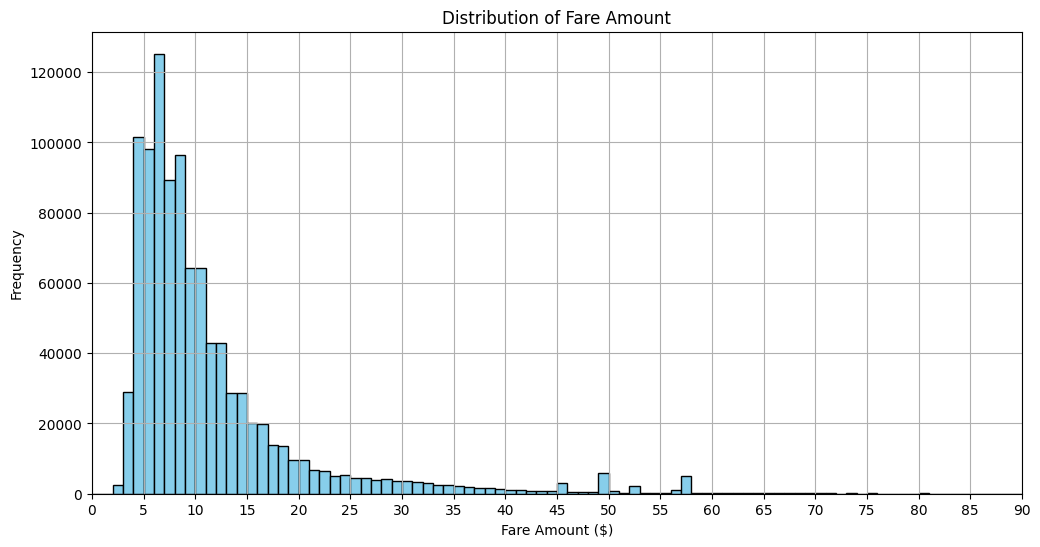

In [8]:
# გამომაქ ფასის განაწილების გრაფიკი
plt.figure(figsize=(12, 6))
plt.hist(train_df['fare_amount'], bins=np.arange(0, 121, 1), color='skyblue', edgecolor='black')
plt.title('Distribution of Fare Amount')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Frequency')
plt.grid(True)
plt.xticks(np.arange(0, 121, 5))
plt.xlim(0, 90) 
plt.show()

In [9]:
# გამომაქ რამდენი % არის 90$-ს ქვემოთ (ანუ ამ განაწილებაში მონაცემების რამდენი % მოხვდა)
total_records = len(train_df)
records_under_90 = train_df[train_df['fare_amount'] < 90]
percentage_under_90 = (len(records_under_90) / total_records) * 100
print(f"The percentage of fare_amount under $90 is: {percentage_under_90:.2f}%")

The percentage of fare_amount under $90 is: 99.94%


In [10]:
# დროს ვხლიჩავ (დღე,წელი,თვე და დრო) შემდეგ კი ვამატებ ახალ field-ებს data-ში
train_df['key'] = pd.to_datetime(train_df['key'])

train_df['year'] = train_df['key'].dt.year
train_df['month'] = train_df['key'].dt.month
train_df['day'] = train_df['key'].dt.day
train_df['time'] = train_df['key'].dt.strftime('%H:%M:%S')

train_df.head()


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,time
0,2009-06-15 17:26:21.000000100,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1,2009,6,15,17:26:21
1,2010-01-05 16:52:16.000000200,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1,2010,1,5,16:52:16
2,2011-08-18 00:35:00.000000490,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2,2011,8,18,00:35:00
3,2012-04-21 04:30:42.000000100,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1,2012,4,21,04:30:42
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1,2010,3,9,07:51:00


In [11]:
print(train_df.count())

key                  995910
fare_amount          995910
pickup_datetime      995910
pickup_longitude     995910
pickup_latitude      995910
dropoff_longitude    995910
dropoff_latitude     995910
passenger_count      995910
year                 995910
month                995910
day                  995910
time                 995910
dtype: int64


In [12]:
from datetime import datetime

# ვამატებ კვირის დღის field-ს
train_df['pickup_datetime'] = pd.to_datetime(train_df[['year', 'month', 'day']])
train_df['day_of_week'] = train_df['pickup_datetime'].dt.day_name()

train_df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,time,day_of_week
0,2009-06-15 17:26:21.000000100,4.5,2009-06-15,-73.844311,40.721319,-73.841610,40.712278,1,2009,6,15,17:26:21,Monday
1,2010-01-05 16:52:16.000000200,16.9,2010-01-05,-74.016048,40.711303,-73.979268,40.782004,1,2010,1,5,16:52:16,Tuesday
2,2011-08-18 00:35:00.000000490,5.7,2011-08-18,-73.982738,40.761270,-73.991242,40.750562,2,2011,8,18,00:35:00,Thursday
3,2012-04-21 04:30:42.000000100,7.7,2012-04-21,-73.987130,40.733143,-73.991567,40.758092,1,2012,4,21,04:30:42,Saturday
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09,-73.968095,40.768008,-73.956655,40.783762,1,2010,3,9,07:51:00,Tuesday


In [13]:
day_to_one_hot = {
    'Monday': [1, 0, 0, 0, 0, 0, 0],
    'Tuesday': [0, 1, 0, 0, 0, 0, 0],
    'Wednesday': [0, 0, 1, 0, 0, 0, 0],
    'Thursday': [0, 0, 0, 1, 0, 0, 0],
    'Friday': [0, 0, 0, 0, 1, 0, 0],
    'Saturday': [0, 0, 0, 0, 0, 1, 0],
    'Sunday': [0, 0, 0, 0, 0, 0, 1]
}

# ვამატებ კვირის დღის one hot წარმოდგენას
train_df['one_hot_encoding_day'] = train_df['day_of_week'].map(lambda x: day_to_one_hot[x])


print(train_df)

                                 key  fare_amount pickup_datetime  \
0      2009-06-15 17:26:21.000000100          4.5      2009-06-15   
1      2010-01-05 16:52:16.000000200         16.9      2010-01-05   
2      2011-08-18 00:35:00.000000490          5.7      2011-08-18   
3      2012-04-21 04:30:42.000000100          7.7      2012-04-21   
4      2010-03-09 07:51:00.000000135          5.3      2010-03-09   
...                              ...          ...             ...   
999995 2014-09-13 21:44:38.000000100          7.0      2014-09-13   
999996 2010-09-20 14:50:37.000000200          7.3      2010-09-20   
999997 2013-04-26 14:03:00.000000118         10.5      2013-04-26   
999998 2011-07-08 00:29:00.000000990          6.9      2011-07-08   
999999 2009-12-31 14:30:00.000000210          4.1      2009-12-31   

        pickup_longitude  pickup_latitude  dropoff_longitude  \
0             -73.844311        40.721319         -73.841610   
1             -74.016048        40.711303  

In [14]:
train_df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,time,day_of_week,one_hot_encoding_day
0,2009-06-15 17:26:21.000000100,4.5,2009-06-15,-73.844311,40.721319,-73.841610,40.712278,1,2009,6,15,17:26:21,Monday,"[1, 0, 0, 0, 0, 0, 0]"
1,2010-01-05 16:52:16.000000200,16.9,2010-01-05,-74.016048,40.711303,-73.979268,40.782004,1,2010,1,5,16:52:16,Tuesday,"[0, 1, 0, 0, 0, 0, 0]"
2,2011-08-18 00:35:00.000000490,5.7,2011-08-18,-73.982738,40.761270,-73.991242,40.750562,2,2011,8,18,00:35:00,Thursday,"[0, 0, 0, 1, 0, 0, 0]"
3,2012-04-21 04:30:42.000000100,7.7,2012-04-21,-73.987130,40.733143,-73.991567,40.758092,1,2012,4,21,04:30:42,Saturday,"[0, 0, 0, 0, 0, 1, 0]"
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09,-73.968095,40.768008,-73.956655,40.783762,1,2010,3,9,07:51:00,Tuesday,"[0, 1, 0, 0, 0, 0, 0]"


In [15]:
train_df['pickup_datetime']

0        2009-06-15
1        2010-01-05
2        2011-08-18
3        2012-04-21
4        2010-03-09
            ...    
999995   2014-09-13
999996   2010-09-20
999997   2013-04-26
999998   2011-07-08
999999   2009-12-31
Name: pickup_datetime, Length: 995910, dtype: datetime64[ns]

In [16]:
print(min(train_df['year']))
print(max(train_df['year']))

2009
2015


In [17]:
year_to_one_hot = {
    2009: [1, 0, 0, 0, 0, 0, 0],
    2010: [0, 1, 0, 0, 0, 0, 0],
    2011: [0, 0, 1, 0, 0, 0, 0],
    2012: [0, 0, 0, 1, 0, 0, 0],
    2013: [0, 0, 0, 0, 1, 0, 0],
    2014: [0, 0, 0, 0, 0, 1, 0],
    2015: [0, 0, 0, 0, 0, 0, 1]
}
# ვამატებ წელიწადის დროიდ one hot წარმოდგენას
train_df['one_hot_encoding_year'] = train_df['year'].map(lambda x: year_to_one_hot[x])

print(train_df)


                                 key  fare_amount pickup_datetime  \
0      2009-06-15 17:26:21.000000100          4.5      2009-06-15   
1      2010-01-05 16:52:16.000000200         16.9      2010-01-05   
2      2011-08-18 00:35:00.000000490          5.7      2011-08-18   
3      2012-04-21 04:30:42.000000100          7.7      2012-04-21   
4      2010-03-09 07:51:00.000000135          5.3      2010-03-09   
...                              ...          ...             ...   
999995 2014-09-13 21:44:38.000000100          7.0      2014-09-13   
999996 2010-09-20 14:50:37.000000200          7.3      2010-09-20   
999997 2013-04-26 14:03:00.000000118         10.5      2013-04-26   
999998 2011-07-08 00:29:00.000000990          6.9      2011-07-08   
999999 2009-12-31 14:30:00.000000210          4.1      2009-12-31   

        pickup_longitude  pickup_latitude  dropoff_longitude  \
0             -73.844311        40.721319         -73.841610   
1             -74.016048        40.711303  

-3377.680935
2522.271325


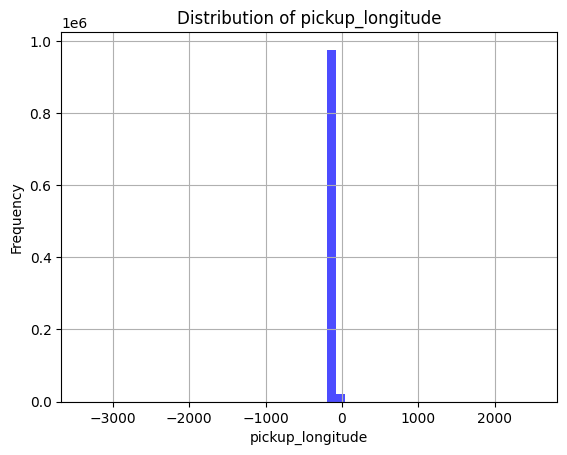

In [18]:
#ვბეჭდავ გრძედისა და განედის განაწილებებს იმისათვის რომ აუთლაიერები გადავაგდო
print(min(train_df['pickup_longitude']))
print(max(train_df['pickup_longitude']))

plt.hist(train_df['pickup_longitude'], bins=50, color='blue', alpha=0.7)
plt.xlabel('pickup_longitude')
plt.ylabel('Frequency')
plt.title('Distribution of pickup_longitude')
plt.grid(True)
plt.show()

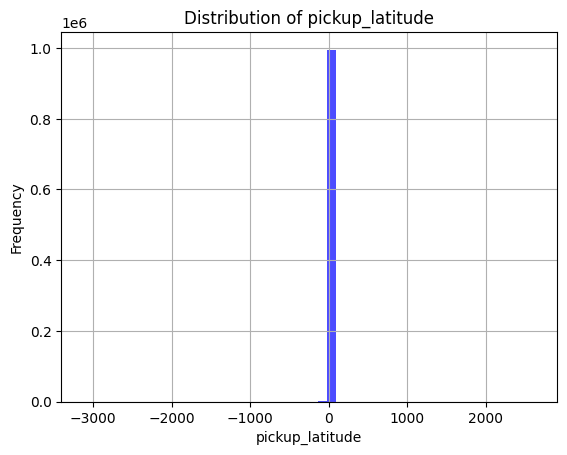

In [19]:
#ვბეჭდავ გრძედისა და განედის განაწილებებს იმისათვის რომ აუთლაიერები გადავაგდო
plt.hist(train_df['pickup_latitude'], bins=50, color='blue', alpha=0.7)
plt.xlabel('pickup_latitude')
plt.ylabel('Frequency')
plt.title('Distribution of pickup_latitude')
plt.grid(True)
plt.show()

-3383.296608
45.581619


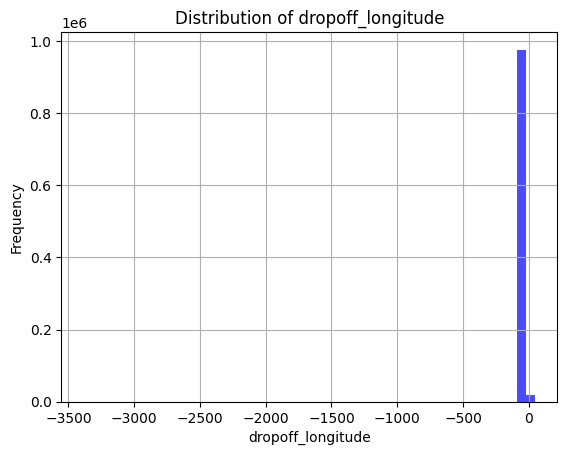

In [20]:
#ვბეჭდავ გრძედისა და განედის განაწილებებს იმისათვის რომ აუთლაიერები გადავაგდო
print(min(train_df['dropoff_longitude']))
print(max(train_df['dropoff_longitude']))

plt.hist(train_df['dropoff_longitude'], bins=50, color='blue', alpha=0.7)
plt.xlabel('dropoff_longitude')
plt.ylabel('Frequency')
plt.title('Distribution of dropoff_longitude')
plt.grid(True)
plt.show()

-3116.285383
2621.62843


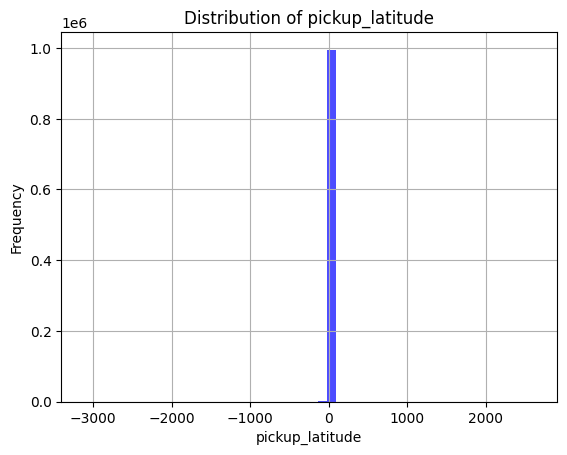

In [21]:
#ვბეჭდავ გრძედისა და განედის განაწილებებს იმისათვის რომ აუთლაიერები გადავაგდო
print(min(train_df['pickup_latitude']))
print(max(train_df['pickup_latitude']))

plt.hist(train_df['pickup_latitude'], bins=50, color='blue', alpha=0.7)
plt.xlabel('pickup_latitude')
plt.ylabel('Frequency')
plt.title('Distribution of pickup_latitude')
plt.grid(True)
plt.show()

In [22]:
# ამ შუალედებში არის ნიუ იორკი ამიტომ აუთლაიერებს ასე გადავყრი
train_df = train_df[(train_df['pickup_longitude'].between(-74.05, -73.75)) &
                    (train_df['pickup_latitude'].between(40.64, 40.84)) &
                    (train_df['dropoff_longitude'].between(-74.05, -73.75)) &
                    (train_df['dropoff_latitude'].between(40.64, 40.84))]


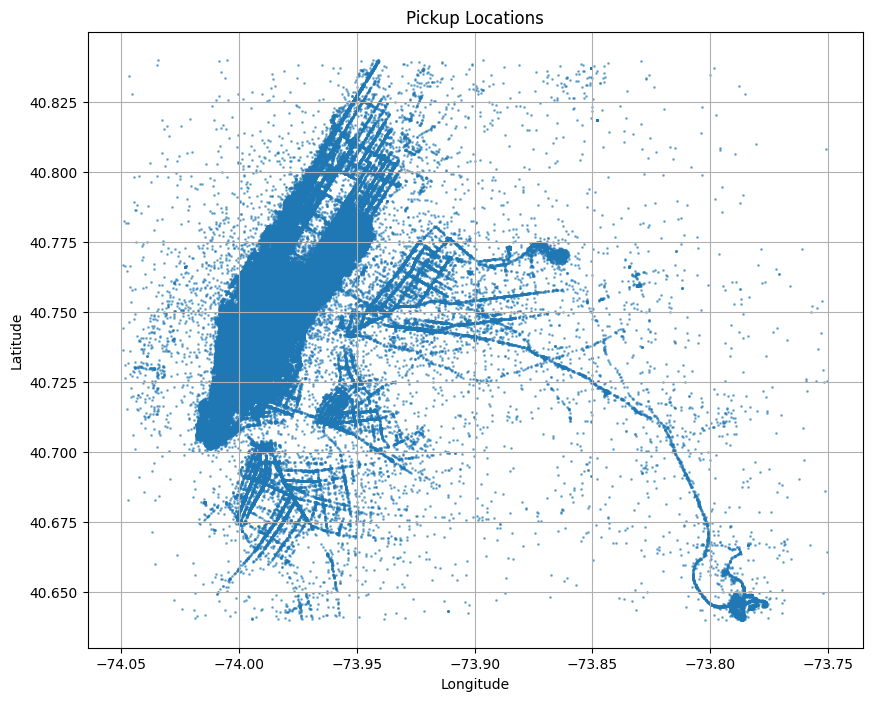

In [23]:
# ვბეჭდავ ტაქსში ჩაჯდომის კოორდინატებს
plt.figure(figsize=(10, 8))
plt.scatter(train_df['pickup_longitude'], train_df['pickup_latitude'], s=1, alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Pickup Locations')
plt.grid(True)
plt.show()
# ეს უკვე გავს ნიუ იორკის გზებს

In [24]:
print(min(train_df['passenger_count']))
print(max(train_df['passenger_count']))
train_df = train_df[train_df['passenger_count'] != 0]
print(min(train_df['passenger_count']))
print(max(train_df['passenger_count']))

0
6
1
6


In [25]:
#ფუნქცია გამოითვლის ორ წერტილს შორის მანძილს სფეროზე
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  
    return c * r

#ვამატებ ახალ field-ს დისტანცია
train_df['distance'] = haversine(train_df['pickup_longitude'], 
                                 train_df['pickup_latitude'],
                                 train_df['dropoff_longitude'], 
                                 train_df['dropoff_latitude'])

print(train_df.head())


                            key  fare_amount pickup_datetime  \
0 2009-06-15 17:26:21.000000100          4.5      2009-06-15   
1 2010-01-05 16:52:16.000000200         16.9      2010-01-05   
2 2011-08-18 00:35:00.000000490          5.7      2011-08-18   
3 2012-04-21 04:30:42.000000100          7.7      2012-04-21   
4 2010-03-09 07:51:00.000000135          5.3      2010-03-09   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.844311        40.721319         -73.841610         40.712278   
1        -74.016048        40.711303         -73.979268         40.782004   
2        -73.982738        40.761270         -73.991242         40.750562   
3        -73.987130        40.733143         -73.991567         40.758092   
4        -73.968095        40.768008         -73.956655         40.783762   

   passenger_count  year  month  day      time day_of_week  \
0                1  2009      6   15  17:26:21      Monday   
1                1  2010    

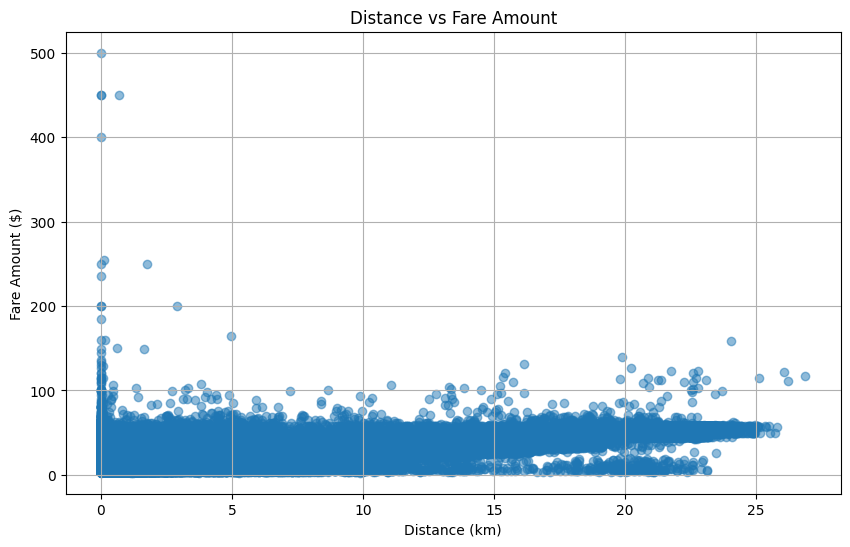

In [26]:
# დისტანციისა და თანხის დამოკიდებულების გრაფიკი
plt.figure(figsize=(10, 6))
plt.scatter(train_df['distance'], train_df['fare_amount'], alpha=0.5)
plt.title('Distance vs Fare Amount')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.show()

In [27]:
print(max(train_df['fare_amount']))
print(min(train_df['fare_amount']))

500.0
2.51


In [28]:
train_df = train_df[(train_df['fare_amount'].between(2.5, 85))]

In [29]:
print(max(train_df['fare_amount']))
print(min(train_df['fare_amount']))

85.0
2.51


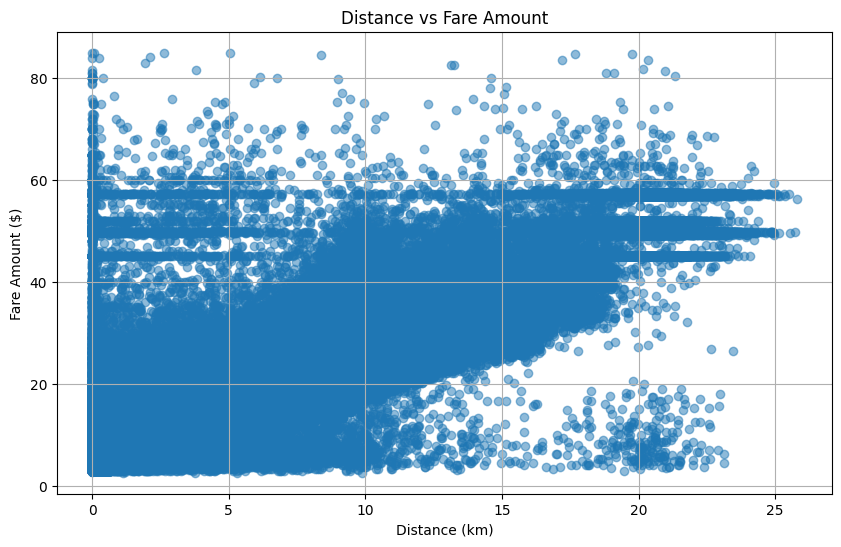

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(train_df['distance'], train_df['fare_amount'], alpha=0.5)
plt.title('Distance vs Fare Amount')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.show()

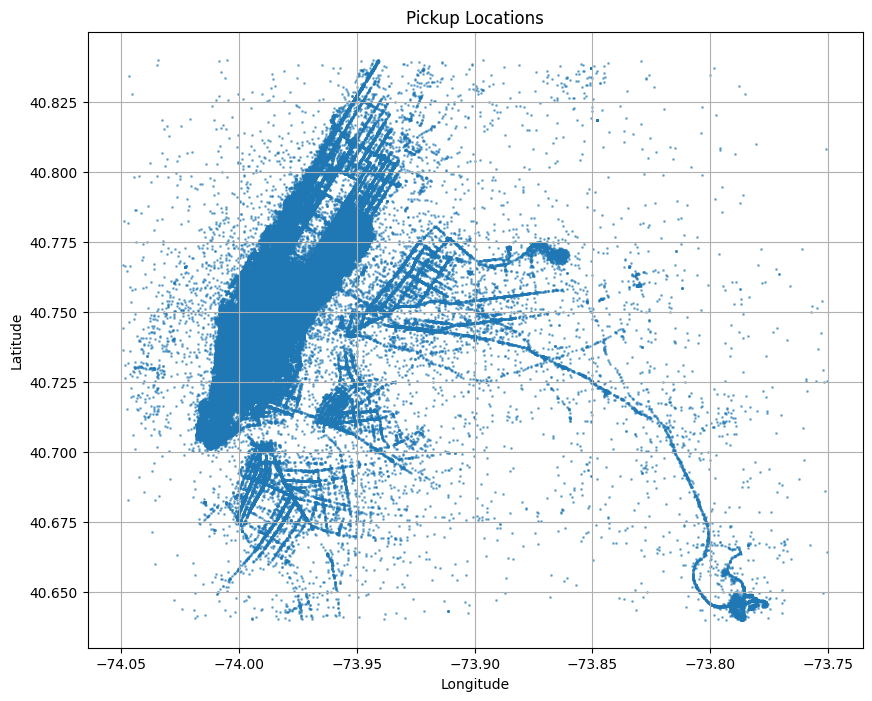

In [31]:
#ფასის აუთლაიერები მოვაშორე და ხელახლა გამომაქ გრაფიკი
plt.figure(figsize=(10, 8))
plt.scatter(train_df['pickup_longitude'], train_df['pickup_latitude'], s=1, alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Pickup Locations')
plt.grid(True)
plt.show()


In [32]:
# ვყოფ გრძედსა და განედს 0 დან 100 მდე სექტორებად რათა დისიჟენ ხეებში გამოვიყენო
print(min(train_df['pickup_longitude']))
print(max(train_df['pickup_longitude']))

-74.049367
-73.750322


In [33]:
#აყვანის გრძედს ვასკალირებ 0 დან 100 მდე შუალედში
min_longitude = min(train_df['pickup_longitude'])
max_longitude = max(train_df['pickup_longitude'])
num_sectors = 100

bin_edges = pd.cut(
    train_df['pickup_longitude'],
    bins=num_sectors,
    labels=range(1, num_sectors + 1),
    include_lowest=True
)


In [34]:
# ვამატებ ახალ field-ს დატაში pickup_longitude_sector (0-100 შუალედშია)
train_df['pickup_longitude_sector'] = bin_edges

train_df['pickup_longitude_sector'] = train_df['pickup_longitude_sector'].astype(int)


In [35]:
#ვბეჭდავ შედეგს
print(train_df[['pickup_longitude', 'pickup_longitude_sector']])

        pickup_longitude  pickup_longitude_sector
0             -73.844311                       69
1             -74.016048                       12
2             -73.982738                       23
3             -73.987130                       21
4             -73.968095                       28
...                  ...                      ...
999995        -73.976676                       25
999996        -73.992103                       20
999997        -73.978423                       24
999998        -73.980317                       24
999999        -74.006635                       15

[955722 rows x 2 columns]


In [36]:
#ვამოწმედ მოხვდა თუ არა 1-100 შუალედში
print(min(train_df['pickup_longitude_sector']))
print(max(train_df['pickup_longitude_sector']))

1
100


In [37]:
#იგივეს ვაკეთებ განედზე

In [38]:
min_longitude = min(train_df['pickup_latitude'])
max_longitude = max(train_df['pickup_latitude'])
num_sectors = 100

bin_edges = pd.cut(
    train_df['pickup_latitude'],
    bins=num_sectors,
    labels=range(1, num_sectors + 1),
    include_lowest=True
)


In [39]:
train_df['pickup_latitude_sector'] = bin_edges

train_df['pickup_latitude_sector'] = train_df['pickup_latitude_sector'].astype(int)

print(train_df[['pickup_latitude', 'pickup_latitude_sector']])


print(min(train_df['pickup_latitude_sector']))
print(max(train_df['pickup_latitude_sector']))

        pickup_latitude  pickup_latitude_sector
0             40.721319                      41
1             40.711303                      36
2             40.761270                      61
3             40.733143                      47
4             40.768008                      65
...                 ...                     ...
999995        40.785630                      73
999996        40.671385                      16
999997        40.751135                      56
999998        40.759482                      60
999999        40.741598                      51

[955722 rows x 2 columns]
1
100


In [40]:
#ვაკეთებ იმავეს ჩასვლის ლოკაციის გრძედზე და განედზე

In [41]:
min_longitude = min(train_df['dropoff_longitude'])
max_longitude = max(train_df['dropoff_longitude'])
num_sectors = 100

bin_edges = pd.cut(
    train_df['dropoff_longitude'],
    bins=num_sectors,
    labels=range(1, num_sectors + 1),
    include_lowest=True
)

train_df['dropoff_longitude_sector'] = bin_edges

# If you want to ensure the sector numbers are integers
train_df['dropoff_longitude_sector'] = train_df['pickup_longitude_sector'].astype(int)

print(train_df[['dropoff_longitude', 'dropoff_longitude_sector']])

print(min(train_df['dropoff_longitude_sector']))
print(max(train_df['dropoff_longitude_sector']))

        dropoff_longitude  dropoff_longitude_sector
0              -73.841610                        69
1              -73.979268                        12
2              -73.991242                        23
3              -73.991567                        21
4              -73.956655                        28
...                   ...                       ...
999995         -73.959196                        25
999996         -73.992103                        20
999997         -73.993397                        24
999998         -73.976832                        24
999999         -73.999450                        15

[955722 rows x 2 columns]
1
100


In [42]:
#განედზე:

In [43]:
min_longitude = min(train_df['dropoff_latitude'])
max_longitude = max(train_df['dropoff_latitude'])
num_sectors = 100

bin_edges = pd.cut(
    train_df['dropoff_latitude'],
    bins=num_sectors,
    labels=range(1, num_sectors + 1),
    include_lowest=True
)

train_df['dropoff_latitude_sector'] = bin_edges

# If you want to ensure the sector numbers are integers
train_df['dropoff_latitude_sector'] = train_df['dropoff_latitude_sector'].astype(int)

print(train_df[['dropoff_latitude', 'dropoff_latitude_sector']])

print(min(train_df['dropoff_latitude_sector']))
print(max(train_df['dropoff_latitude_sector']))

        dropoff_latitude  dropoff_latitude_sector
0              40.712278                       37
1              40.782004                       72
2              40.750562                       56
3              40.758092                       60
4              40.783762                       72
...                  ...                      ...
999995         40.775114                       68
999996         40.671385                       16
999997         40.762197                       62
999998         40.743122                       52
999999         40.745702                       53

[955722 rows x 2 columns]
1
100


In [44]:
# მე მინდა რომ 2D ში სექტორების სიახლოვე რიცხვით სიახლოეში გამოიხატოს.ამიტომ ასე ვაკეთებ 
# გარდავქმნი რიცხვებს ორობით სისტემაში და შემდგომ ვაკეთებ ასე:
# ვიღებ პირველი რიცხვის პირველ ცფრს მერე,მეორე რიცხვის პირველ ციფრს,მერე პირველი რიცხვის მეორე ციფრს და ა.შ. 
#ასეთი შეერთებით ვიღებ სექტორის საბოლოო რიცხვს
# და ამ რიცხვებს შორის სიახლოვის დამოკიდებულება იქმნება. ანუ ახლო საქტორების რიცხვებს შორის სხვაობა ნაკლები იქნება


#გადაიყვანე ორობითში
def calculate_binary(x, length=7):
    binary = bin(x)[2:]  
    padded_binary = binary.zfill(length) 
    return padded_binary

In [45]:
#შეართე რიცხვები
def mix_strings(str1, str2):
    mixed = []
    
    for i in range(7):
        mixed.append(str1[i])
        mixed.append(str2[i])
    
    return ''.join(mixed)


In [46]:
print(train_df)

                                 key  fare_amount pickup_datetime  \
0      2009-06-15 17:26:21.000000100          4.5      2009-06-15   
1      2010-01-05 16:52:16.000000200         16.9      2010-01-05   
2      2011-08-18 00:35:00.000000490          5.7      2011-08-18   
3      2012-04-21 04:30:42.000000100          7.7      2012-04-21   
4      2010-03-09 07:51:00.000000135          5.3      2010-03-09   
...                              ...          ...             ...   
999995 2014-09-13 21:44:38.000000100          7.0      2014-09-13   
999996 2010-09-20 14:50:37.000000200          7.3      2010-09-20   
999997 2013-04-26 14:03:00.000000118         10.5      2013-04-26   
999998 2011-07-08 00:29:00.000000990          6.9      2011-07-08   
999999 2009-12-31 14:30:00.000000210          4.1      2009-12-31   

        pickup_longitude  pickup_latitude  dropoff_longitude  \
0             -73.844311        40.721319         -73.841610   
1             -74.016048        40.711303  

In [47]:
#გადაიყვანე სექტორები ორობითში
train_df['pickup_longitude_binary'] = train_df['pickup_longitude_sector'].apply(calculate_binary)
train_df['pickup_latitude_binary'] = train_df['pickup_latitude_sector'].apply(calculate_binary)
train_df['dropoff_longitude_binary'] = train_df['dropoff_longitude_sector'].apply(calculate_binary)
train_df['dropoff_latitude_binary'] = train_df['dropoff_latitude_sector'].apply(calculate_binary)


In [48]:
#შექმენი სექტორების სიახლოვეზე დამოკიდებული უნიკალური სექტორების ნომრები
train_df['pickup_sector'] = train_df.apply(lambda row: mix_strings(row['pickup_longitude_binary'], row['pickup_latitude_binary']), axis=1)
train_df['dropoff_sector'] = train_df.apply(lambda row: mix_strings(row['dropoff_longitude_binary'], row['dropoff_latitude_binary']), axis=1)


In [49]:
train_df.describe

<bound method NDFrame.describe of                                  key  fare_amount pickup_datetime  \
0      2009-06-15 17:26:21.000000100          4.5      2009-06-15   
1      2010-01-05 16:52:16.000000200         16.9      2010-01-05   
2      2011-08-18 00:35:00.000000490          5.7      2011-08-18   
3      2012-04-21 04:30:42.000000100          7.7      2012-04-21   
4      2010-03-09 07:51:00.000000135          5.3      2010-03-09   
...                              ...          ...             ...   
999995 2014-09-13 21:44:38.000000100          7.0      2014-09-13   
999996 2010-09-20 14:50:37.000000200          7.3      2010-09-20   
999997 2013-04-26 14:03:00.000000118         10.5      2013-04-26   
999998 2011-07-08 00:29:00.000000990          6.9      2011-07-08   
999999 2009-12-31 14:30:00.000000210          4.1      2009-12-31   

        pickup_longitude  pickup_latitude  dropoff_longitude  \
0             -73.844311        40.721319         -73.841610   
1        

In [50]:
train_df.dtypes

key                         datetime64[ns]
fare_amount                        float64
pickup_datetime             datetime64[ns]
pickup_longitude                   float64
pickup_latitude                    float64
dropoff_longitude                  float64
dropoff_latitude                   float64
passenger_count                      int64
year                                 int32
month                                int32
day                                  int32
time                                object
day_of_week                         object
one_hot_encoding_day                object
one_hot_encoding_year               object
distance                           float64
pickup_longitude_sector              int32
pickup_latitude_sector               int32
dropoff_longitude_sector             int32
dropoff_latitude_sector              int32
pickup_longitude_binary             object
pickup_latitude_binary              object
dropoff_longitude_binary            object
dropoff_lat

In [51]:
#ვამატებ საათს წუთს და წამს
train_df['hour'] = pd.to_datetime(train_df['time']).dt.hour
train_df['minute'] = pd.to_datetime(train_df['time']).dt.minute
train_df['second'] = pd.to_datetime(train_df['time']).dt.second

C:\Users\LG\AppData\Local\Temp\ipykernel_11704\1027796448.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df['hour'] = pd.to_datetime(train_df['time']).dt.hour
C:\Users\LG\AppData\Local\Temp\ipykernel_11704\1027796448.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df['minute'] = pd.to_datetime(train_df['time']).dt.minute
C:\Users\LG\AppData\Local\Temp\ipykernel_11704\1027796448.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df['second'] = pd.to_datetime(train_df['time']).dt.second


In [52]:
#ორობითიდან ისევ უკან ათობითში უნდა გადავიყვანო რადგან დაშორებები 1100 და 0011- შორის ათობითში მეტად დიდია
#და თუ მე მინდა რომ ახლო სექტორები ახლო რიცხვებთან იყოს ასოცირებული მაშინ უკან უნდა გადავიყვანო ათობითში
def binary_to_int(binary_str):
    return int(binary_str, 2)

In [53]:
train_df['pickup'] = train_df['pickup_sector'].apply(binary_to_int)
train_df['dropoff'] = train_df['dropoff_sector'].apply(binary_to_int)

In [54]:
train_df['pickup']

0         9315
1         1200
2         1915
3         1655
4         4769
          ... 
999995    4803
999996     800
999997    1984
999998    2000
999999    1455
Name: pickup, Length: 955722, dtype: int64

In [55]:
train_df.shape

(955722, 31)

In [56]:
one_hot_encoding_year = np.array(train_df['one_hot_encoding_year'].tolist())
one_hot_encoding_day = np.array(train_df['one_hot_encoding_day'].tolist())
passenger_count = train_df['passenger_count']
month = train_df['month']
day = train_df['day']
distance = train_df['distance']
pickup = train_df['pickup']
dropoff = train_df['dropoff']


In [57]:
train_df.dtypes

key                         datetime64[ns]
fare_amount                        float64
pickup_datetime             datetime64[ns]
pickup_longitude                   float64
pickup_latitude                    float64
dropoff_longitude                  float64
dropoff_latitude                   float64
passenger_count                      int64
year                                 int32
month                                int32
day                                  int32
time                                object
day_of_week                         object
one_hot_encoding_day                object
one_hot_encoding_year               object
distance                           float64
pickup_longitude_sector              int32
pickup_latitude_sector               int32
dropoff_longitude_sector             int32
dropoff_latitude_sector              int32
pickup_longitude_binary             object
pickup_latitude_binary              object
dropoff_longitude_binary            object
dropoff_lat

In [58]:
# ბუნებრივია, რომ მგზავრთა რაოდენობით და დისტანციით რაც მეტია მით მეტი ფასის გადახდა გვიწევს 
# ამიტომ გავაკეთებ მარტივ რეგრესიას ამ ორ ცვლადზე

In [59]:
data = train_df[['passenger_count', 'distance', 'fare_amount']]

X = data[['passenger_count', 'distance']]
y = data['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 17.46602859665427


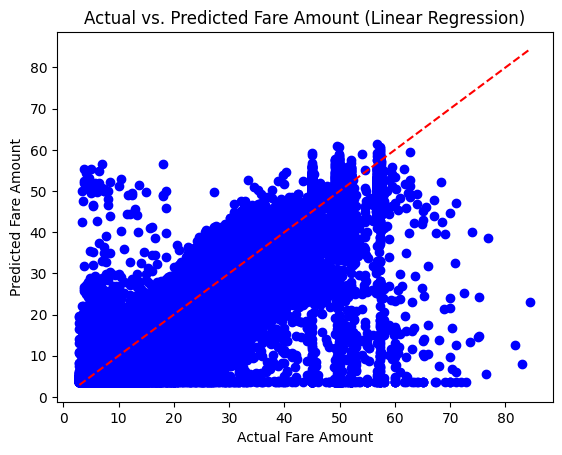

In [60]:
#რეგრესიის ვიზუალიზაცია
#(ამის ოპტიმიზაციას აღარ გავაკეთებ რათა ნეირონული ქსელი მერე მექნება)
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Fare Amount')
plt.ylabel('Predicted Fare Amount')
plt.title('Actual vs. Predicted Fare Amount (Linear Regression)')
plt.show()

In [61]:
#კვირის დღეები 0 დან 6 მდე რომ გადავნომრო ერთმანეთს შორის ცუდ კავშირებს დაიჭერს ამიტომ one hot მიდგომა ჯობია 
#(წლებზე და კვირის დღეებზე)
one_hot_day = pd.DataFrame(train_df['one_hot_encoding_day'].tolist(), columns=['day_{}'.format(i) for i in range(7)])
one_hot_year = pd.DataFrame(train_df['one_hot_encoding_year'].tolist(), columns=['year_{}'.format(i) for i in range(len(train_df['one_hot_encoding_year'][0]))])


In [62]:
print(one_hot_day)

        day_0  day_1  day_2  day_3  day_4  day_5  day_6
0           1      0      0      0      0      0      0
1           0      1      0      0      0      0      0
2           0      0      0      1      0      0      0
3           0      0      0      0      0      1      0
4           0      1      0      0      0      0      0
...       ...    ...    ...    ...    ...    ...    ...
955717      0      0      0      0      0      1      0
955718      1      0      0      0      0      0      0
955719      0      0      0      0      1      0      0
955720      0      0      0      0      1      0      0
955721      0      0      0      1      0      0      0

[955722 rows x 7 columns]


In [63]:
train_df_encoded = pd.concat([train_df, one_hot_day, one_hot_year], axis=1)


In [64]:
train_df_encoded.drop(['one_hot_encoding_day', 'one_hot_encoding_year'], axis=1, inplace=True)


In [65]:
print(train_df_encoded)

                                 key  fare_amount pickup_datetime  \
0      2009-06-15 17:26:21.000000100          4.5      2009-06-15   
1      2010-01-05 16:52:16.000000200         16.9      2010-01-05   
2      2011-08-18 00:35:00.000000490          5.7      2011-08-18   
3      2012-04-21 04:30:42.000000100          7.7      2012-04-21   
4      2010-03-09 07:51:00.000000135          5.3      2010-03-09   
...                              ...          ...             ...   
955666                           NaT          NaN             NaT   
955669                           NaT          NaN             NaT   
955679                           NaT          NaN             NaT   
955689                           NaT          NaN             NaT   
955701                           NaT          NaN             NaT   

        pickup_longitude  pickup_latitude  dropoff_longitude  \
0             -73.844311        40.721319         -73.841610   
1             -74.016048        40.711303  

In [66]:
train_df_encoded.dtypes

key                         datetime64[ns]
fare_amount                        float64
pickup_datetime             datetime64[ns]
pickup_longitude                   float64
pickup_latitude                    float64
dropoff_longitude                  float64
dropoff_latitude                   float64
passenger_count                    float64
year                               float64
month                              float64
day                                float64
time                                object
day_of_week                         object
distance                           float64
pickup_longitude_sector            float64
pickup_latitude_sector             float64
dropoff_longitude_sector           float64
dropoff_latitude_sector            float64
pickup_longitude_binary             object
pickup_latitude_binary              object
dropoff_longitude_binary            object
dropoff_latitude_binary             object
pickup_sector                       object
dropoff_sec

In [67]:
# საბოლოოდ დათაში არის ის field-ები რომლებიც მხოლოდ სხვა field - ების გამოთვლაში იღებდა მონაწილეობას 
# ხოლო ზოგი სხვა field-ს პირდაპირ მოიცავს
# წამებს კიდე მნიშვნელობა არ ექნება მაგას ამოვიღებ

In [70]:
cleaned_data = train_df_encoded[['fare_amount','passenger_count','month','distance','pickup','dropoff','day_0','day_1','day_2','day_3','day_4','day_5','day_6','year_0','year_1','year_2','year_3','year_4','year_5','year_6','hour','minute' ]].copy()

In [71]:
cleaned_data.dtypes

fare_amount        float64
passenger_count    float64
month              float64
distance           float64
pickup             float64
dropoff            float64
day_0              float64
day_1              float64
day_2              float64
day_3              float64
day_4              float64
day_5              float64
day_6              float64
year_0             float64
year_1             float64
year_2             float64
year_3             float64
year_4             float64
year_5             float64
year_6             float64
hour               float64
minute             float64
dtype: object

In [80]:
#დავყოთ ტრეინ და ვალიდაციის სეტებად
cleaned_data.dropna(inplace=True)

X_train, X_val, y_train, y_val = train_test_split(cleaned_data.drop('fare_amount', axis=1), cleaned_data['fare_amount'], test_size=0.2, random_state=42)


In [81]:
#გავუშვათ XGboost
params1 = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

model1 = xgb.XGBRegressor(**params1)
model1.fit(X_train, y_train)

predictions1 = model1.predict(X_val)

rmse1 = mean_squared_error(y_val, predictions1, squared=False)
print("Model 1 RMSE:", rmse1)

Model 1 RMSE: 3.8422539963907165


C:\Users\LG\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [77]:
#ნორმალური შედეგია ახლა მოვუმატოთ სიღრმე და შევამციროთ learnig rate და ვათამაშოთ სხვა პარამეტრები

Columns with null values:
fare_amount        42326
passenger_count    42326
month              42326
distance           42326
pickup             42326
dropoff            42326
day_0              42326
day_1              42326
day_2              42326
day_3              42326
day_4              42326
day_5              42326
day_6              42326
year_0             42326
year_1             42326
year_2             42326
year_3             42326
year_4             42326
year_5             42326
year_6             42326
hour               42326
minute             42326
dtype: int64


In [82]:
params2 = {
    'objective': 'reg:squarederror',
    'max_depth': 5,
    'learning_rate': 0.05,
    'n_estimators': 200,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'random_state': 42
}

model2 = xgb.XGBRegressor(**params2)
model2.fit(X_train, y_train)

predictions2 = model2.predict(X_val)

rmse2 = mean_squared_error(y_val, predictions2, squared=False)
print("Model 2 RMSE:", rmse2)

Model 2 RMSE: 3.7404545210746116


C:\Users\LG\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
#უკეთესი შედეგია ახლა კიდე მოვუმატოთ სიღრმე და მეტად შევამციროთ learnig rate

In [83]:
params3 = {
    'objective': 'reg:squarederror',
    'max_depth': 7,
    'learning_rate': 0.01,
    'n_estimators': 300,
    'subsample': 0.6,
    'colsample_bytree': 0.6,
    'random_state': 42
}

model3 = xgb.XGBRegressor(**params3)
model3.fit(X_train, y_train)

predictions3 = model3.predict(X_val)

rmse3 = mean_squared_error(y_val, predictions3, squared=False)
print("Model 3 RMSE:", rmse3)

Model 3 RMSE: 3.9097658468789804


C:\Users\LG\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
#ოვერფიტისკენ წავიდა ამიტომ მეორე მოდელის შედეგი საუკეთესო იყო

In [86]:
# ახლა განვიხილოთ bagging მეთოდები
#ვყოგ 80/20 ტრეინ ვალიდაციად
cleaned_data.dropna(inplace=True)

X_train, X_test, y_train, y_test = train_test_split(cleaned_data.drop(columns=['fare_amount']), cleaned_data['fare_amount'], test_size=0.2, random_state=42)


In [93]:
#გავუშვათ რანდომ ფორესტი
rf_model_1 = RandomForestRegressor(n_estimators=5, max_depth=7, random_state=42)
rf_model_1.fit(X_train, y_train)

y_pred_1 = rf_model_1.predict(X_test)
mse_1 = mean_squared_error(y_test, y_pred_1)
print("Mean Squared Error for Model 1:", mse_1)

Mean Squared Error for Model 1: 14.393364233668992


In [ ]:
#ცუდი შედეგია მარა დრო ცოტა დაჭირდა ახლა მოვამატებ n_estimators იგივე სიღრმეზე გავუშვებ

In [94]:
rf_model_1 = RandomForestRegressor(n_estimators=40, max_depth=7, random_state=42)
rf_model_1.fit(X_train, y_train)

# Validation
y_pred_1 = rf_model_1.predict(X_test)
mse_1 = mean_squared_error(y_test, y_pred_1)
print("Mean Squared Error for Model 1:", mse_1)

Mean Squared Error for Model 1: 14.308782014993112


In [ ]:
#ახლა ვცდი ნეირონულ ქსელებს პირდაპირ feed forward- არქიტექტურით

In [ ]:
X = cleaned_data.drop(columns=['fare_amount']).values
y = cleaned_data['fare_amount'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [99]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Build neural network model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_data=(X_val_scaled, y_val))

# Evaluate model
val_loss = model.evaluate(X_val_scaled, y_val)
print("Validation Loss:", val_loss)

# Output predictions on validation set
y_pred = model.predict(X_val_scaled)
print("Predictions on Validation Set:")
print(y_pred)

C:\Users\LG\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:73: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
22835/22835 ━━━━━━━━━━━━━━━━━━━━ 68s 3ms/step - loss: 20.5768 - val_loss: 16.2239
Epoch 2/20
22835/22835 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 15.6604 - val_loss: 15.8216
Epoch 3/20
22835/22835 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - loss: 15.4984 - val_loss: 15.7254
Epoch 4/20
22835/22835 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - loss: 14.9501 - val_loss: 15.4055
Epoch 5/20
22835/22835 ━━━━━━━━━━━━━━━━━━━━ 58s 3ms/step - loss: 14.8442 - val_loss: 15.4196
Epoch 6/20
22835/22835 ━━━━━━━━━━━━━━━━━━━━ 53s 2ms/step - loss: 14.6015 - val_loss: 15.7502
Epoch 7/20
22835/22835 ━━━━━━━━━━━━━━━━━━━━ 51s 2ms/step - loss: 14.6036 - val_loss: 15.0608
Epoch 8/20
22835/22835 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - loss: 14.3590 - val_loss: 14.7830
Epoch 9/20
22835/22835 ━━━━━━━━━━━━━━━━━━━━ 78s 3ms/step - loss: 14.5057 - val_loss: 14.7808
Epoch 10/20
22835/22835 ━━━━━━━━━━━━━━━━━━━━ 78s 3ms/step - loss: 14.1312 - val_loss: 14.7118
Epoch 11/20
22835/22835 ━━━━━━━━━━━━━━━━━━━━ 78s 3ms/step - loss: 14.

In [ ]:
#შესატანი მონაცემები ბევრია მაგრამ რაიმეს გადაყრა არ ღირს რადგან ყველა კომპონენტი მნიშვნელოვანია ამიტომ რაც შეიძლება ცოტა
#ინფორმაცია რომ დამეკარგოს PCA-ით ინფორმაციას განზომილებას შევუმცირებ 22დან 11 ზე დავიყვან (მე-12 ფასი იქნება) 
#და მეტად ბევრ hidden ლეიერიან ქსელში გავუშვებ

In [104]:
cleaned_data = cleaned_data[[col for col in cleaned_data if col != 'fare_amount'] + ['fare_amount']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cleaned_data)

pca = PCA(n_components=12)
pca_data = pca.fit_transform(scaled_data)

new_data = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'fare_amount'])


In [103]:
new_data.shape

(913396, 12)

In [ ]:
X = new_data.drop(columns=['fare_amount'])
y = new_data['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(11,)),
    tf.keras.layers.Dropout(0.05),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.05),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.05),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.05),
    tf.keras.layers.Dense(1)  # Output layer
])

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

loss = model.evaluate(X_test_scaled, y_test)
print("Test Loss:", loss)

In [107]:
#ამის დატრეინინგებას აღარ დავიწყებ ძალიან დიდი დრო დაჭირდა და მაინც ცუდი შედეგი მომცა ვიფიქრე რადგან ოვერფიტი არ არი
#dropout - ებს წავუშლი მაინც ტყვილა აფუჭებს შედეგსთქო მარა მაგან მაინც =8 შედეგი მომცა


In [ ]:
X = new_data.drop(columns=['fare_amount'])
y = new_data['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(11,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1) 
])

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

loss = model.evaluate(X_test_scaled, y_test)
print("Test Loss:", loss)

In [ ]:
#ყველაზე კარგი შედეგი xgboost-მა მომცა -3
#კეგლზე 4.4532